In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle

In [49]:
filename = "./solutions/debug/Crippa_1h_TotalRefreezing.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
W = functionspace(domain, ("DG", 1))
hw = Function(V)
phi = Function(Q)
T_i = Function(W)
T_w = Function(W)
p = Parameter(domain)

In [50]:
len(data_Annika["h_w"])

2

In [51]:
interval = data_Annika["saving_interval"]
t_obs = -1
hw.x.array[:] = data_Annika["h_w"][t_obs]
phi.x.array[:] = data_Annika["phi"][t_obs]
T_i.x.array[:] = data_Annika["T_i"][t_obs]
T_w.x.array[:] = data_Annika["T_w"][t_obs]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
Ti = eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx))
Tw = eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx))
h_c = pressure_head * (pressure_head < 0)
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, p.alpha.value, p.N.value)

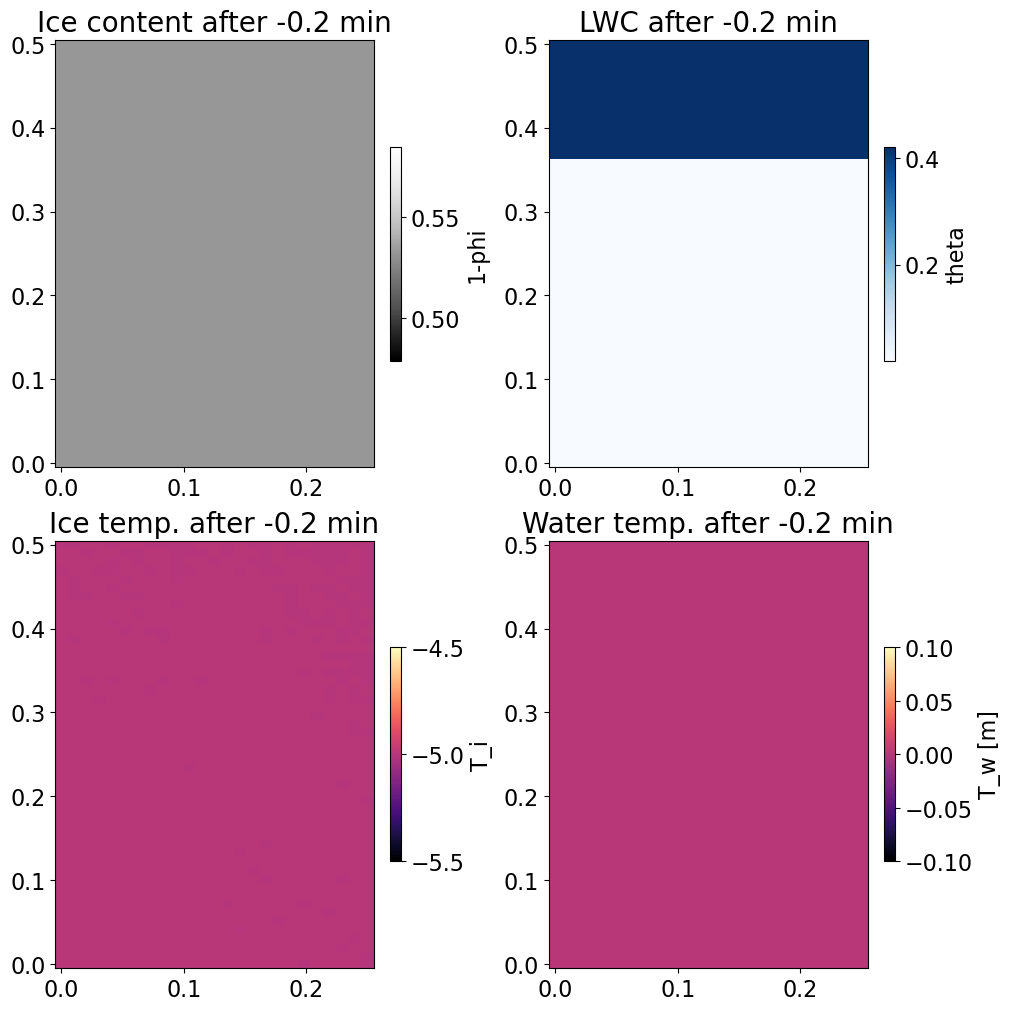

In [52]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(2,2, layout="constrained", figsize=(10,10))
pmsh1 = ax[0,0].pcolormesh(x_plot, z_plot, (1-porosity), cmap="Greys_r")
ax[0,0].set_title(f"Ice content after {t_obs*interval/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0,0], shrink=0.5)
cbar1.set_label("1-phi")

pmsh2 = ax[0,1].pcolormesh(x_plot, z_plot, theta_tot, cmap="Blues")
ax[0,1].set_title(f"LWC after {t_obs*interval/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh2, ax=ax[0,1], shrink=0.5)
cbar2.set_label("theta")

pmsh3 = ax[1,0].pcolormesh(x_plot, z_plot, Ti, cmap="magma")
ax[1,0].set_title(f"Ice temp. after {t_obs*interval/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh3, ax=ax[1,0], shrink=0.5)
cbar1.set_label("T_i")

pmsh4 = ax[1,1].pcolormesh(x_plot, z_plot, Tw, cmap="magma")
ax[1,1].set_title(f"Water temp. after {t_obs*interval/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh4, ax=ax[1,1], shrink=0.5)
cbar2.set_label("T_w [m]")

In [8]:
Ti

array([[-9.99999499e-01, -9.99999499e-01, -9.99999499e-01, ...,
        -9.99999499e-01, -9.99999499e-01, -9.99999499e-01],
       [-1.87913117e-02, -1.87901149e-02, -1.87889181e-02, ...,
        -1.87649823e-02, -1.87637855e-02, -1.87625888e-02],
       [-1.84311349e-02, -1.84299850e-02, -1.84288352e-02, ...,
        -1.84058377e-02, -1.84046878e-02, -1.84035380e-02],
       ...,
       [-8.43813641e-04, -8.43862438e-04, -8.43911234e-04, ...,
        -8.44887159e-04, -8.44935955e-04, -8.44984751e-04],
       [-4.24073844e-04, -4.24127892e-04, -4.24181940e-04, ...,
        -4.25262901e-04, -4.25316949e-04, -4.25370997e-04],
       [-1.16577690e-18, -1.55893549e-18,  8.65933065e-19, ...,
        -2.72997517e-18, -3.11702325e-18, -1.08158249e-18]],
      shape=(50, 25))

In [21]:
2760/60

46.0